In [65]:
#Task 01 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [49]:
# Load dataset
df = pd.read_csv("BrentOilPrices.csv")

In [51]:
# Display first few rows
display(df.head())

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [53]:
# Check for missing/null values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Date     0
Price    0
dtype: int64


In [55]:
# Convert 'Date' column to datetime format if needed
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Senuji\AppData\Local\Temp\ipykernel_7404\2449511005.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [57]:
# Describe key statistics
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
                                Date        Price
count                           9011  9011.000000
mean   2005-02-10 23:46:53.760958720    48.420782
min              1987-05-20 00:00:00     9.100000
25%              1996-03-20 12:00:00    19.050000
50%              2005-02-02 00:00:00    38.570000
75%              2014-01-09 12:00:00    70.090000
max              2022-11-14 00:00:00   143.950000
std                              NaN    32.860110


In [59]:
# Data coverage (time span and granularity)
start_date = df['Date'].min()
end_date = df['Date'].max()
print(f"\nData covers from {start_date.date()} to {end_date.date()}")


Data covers from 1987-05-20 to 2022-11-14


In [61]:
# Check granularity (frequency of data points)
inferred_freq = pd.infer_freq(df['Date'])
print(f"Inferred frequency: {inferred_freq if inferred_freq else 'Could not determine automatically'}")

Inferred frequency: Could not determine automatically


In [63]:
# Question 02

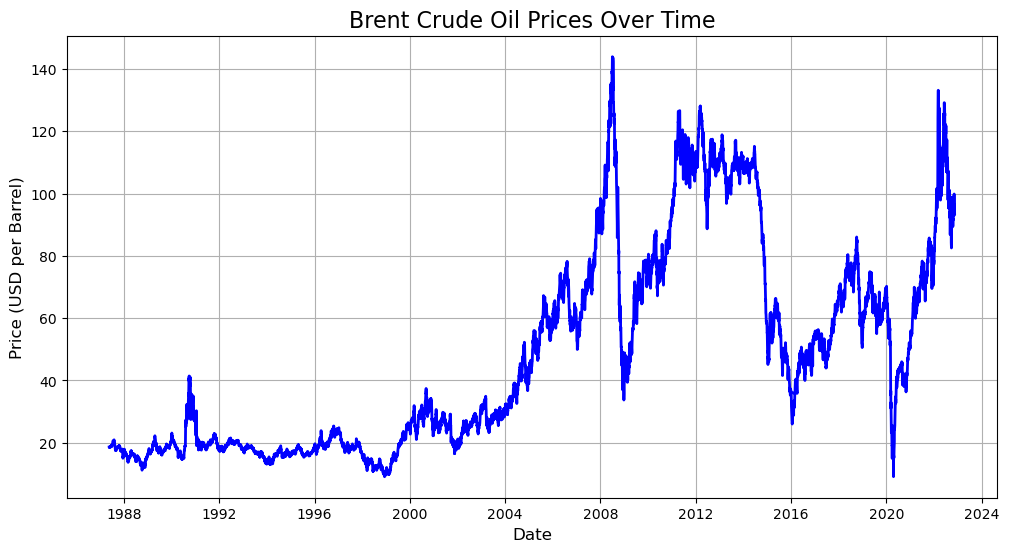

In [67]:
# Create a line chart of oil prices over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Price'], color='blue', linewidth=2)
plt.title("Brent Crude Oil Prices Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD per Barrel)", fontsize=12)
plt.grid(True)
plt.show()

In [69]:
# Question 3

In [71]:
# Create MA3 (3-day moving average) and MA9 (9-day moving average)
df['MA3'] = df['Price'].rolling(window=3).mean()
df['MA9'] = df['Price'].rolling(window=9).mean()

In [73]:
# Display first few rows with new columns
print("First 10 rows with MA3 and MA9:")
display(df.head(10))

First 10 rows with MA3 and MA9:


,Date,Price,MA3,MA9
0,1987-05-20,18.63,NaN,NaN
1,1987-05-21,18.45,NaN,NaN
2,1987-05-22,18.55,18.543333,NaN
3,1987-05-25,18.60,18.533333,NaN
4,1987-05-26,18.63,18.593333,NaN
5,1987-05-27,18.60,18.610000,NaN
6,1987-05-28,18.60,18.610000,NaN
7,1987-05-29,18.58,18.593333,NaN
8,1987-06-01,18.65,18.610000,18.587778
9,1987-06-02,18.68,18.636667,18.593333


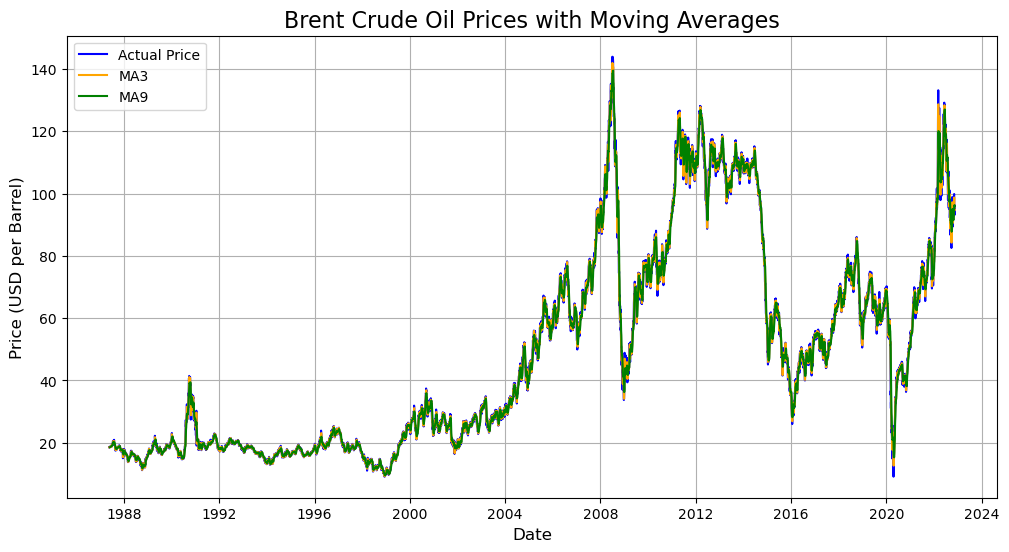

In [75]:
# Plot actual price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Price'], label='Actual Price', color='blue')
plt.plot(df['Date'], df['MA3'], label='MA3', color='orange')
plt.plot(df['Date'], df['MA9'], label='MA9', color='green')
plt.title("Brent Crude Oil Prices with Moving Averages", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD per Barrel)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [96]:
# Question 4

In [77]:
# 4. Prepare Train-Test Sets
from sklearn.model_selection import train_test_split

In [79]:
# Keep only the required columns
df_model = df[['Date', 'Price', 'MA3', 'MA9']].dropna()

In [84]:
# Define features (X) and target (y)
X = df_model[['MA3', 'MA9']]
y = df_model['Price']

In [86]:
# Split into training and testing sets (80/20 split) with reproducible random seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 7202
Testing set size: 1801


In [94]:
# Optional: Show the first few rows of training data
print("\nFirst few rows of training set:")
display(X_train.head())


First few rows of training set:


,MA3,MA9
3193,25.996667,25.493333
1306,21.450000,21.227778
2843,12.630000,12.336667
748,16.733333,16.090000
3792,26.330000,25.806667


In [98]:
# Question 5

In [108]:
# 5. Build and Train Linear Regression Model
from sklearn.linear_model import LinearRegression

In [110]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [112]:
# Display model parameters
print("Model trained successfully.")
print(f"Intercept (α): {model.intercept_}")
print(f"Coefficient for MA3 (β₁): {model.coef_[0]}")
print(f"Coefficient for MA9 (β₂): {model.coef_[1]}")

Model trained successfully.
Intercept (α): 0.018408421874774206
Coefficient for MA3 (β₁): 1.2118501161869644
Coefficient for MA9 (β₂): -0.2122597216743817


In [114]:
# Question 6

In [116]:
# 6. Predict and Evaluate Model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [118]:
# Make predictions on the test set
y_pred = model.predict(X_test)

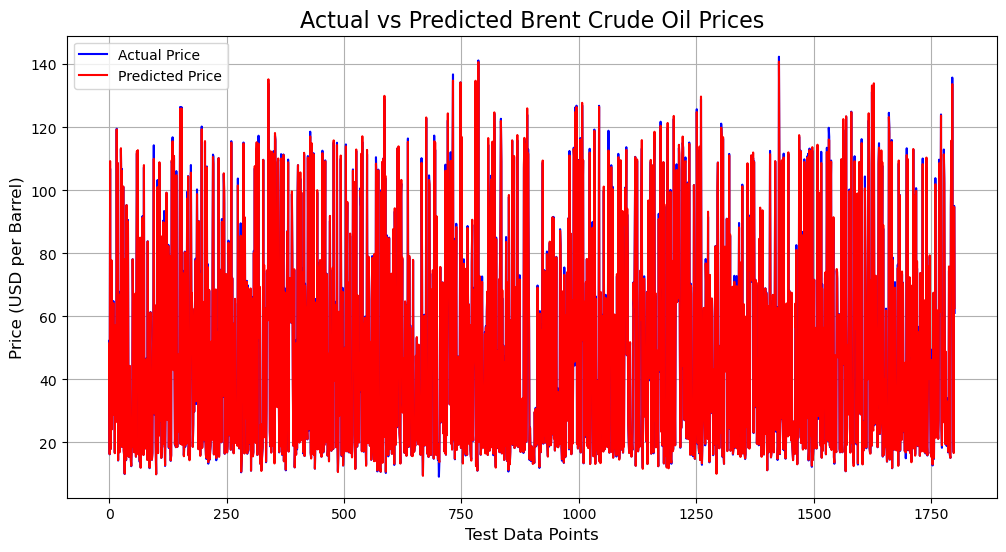

In [120]:
# Compare predicted vs actual prices visually
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red')
plt.title("Actual vs Predicted Brent Crude Oil Prices", fontsize=16)
plt.xlabel("Test Data Points", fontsize=12)
plt.ylabel("Price (USD per Barrel)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [122]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R² Score: 0.9993
Mean Absolute Error (MAE): 0.5439
Root Mean Squared Error (RMSE): 0.8563


In [124]:
# 7. Model Interpretation
# Get model parameters
alpha = model.intercept_
beta1 = model.coef_[0]
beta2 = model.coef_[1]

In [126]:
# Display equation
print("Regression Equation:")
print(f"Price = {alpha:.4f} + ({beta1:.4f} * MA3) + ({beta2:.4f} * MA9)")

Regression Equation:
Price = 0.0184 + (1.2119 * MA3) + (-0.2123 * MA9)
